# Решающее дерево с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите датасет (регрессия или классификация на выбор);
2. реализуете ключевые части решающего дерева **с нуля**:
   - расчет impurity (MSE или Gini);
   - поиск лучшего разбиения (best split);
   - рекурсивное построение дерева;
   - предсказание;
3. обучите свою модель;
4. сравните её качество и структуру с реализацией из `scikit-learn`;
5. поэкспериментируете с параметрами регуляризации (глубина).


## Датасет
Мы будем использовать `California Housing` для задачи **регрессии**. 
- признаки числовые;
- удобен для визуализации важности признаков и структуры дерева.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Шаг 1. Загрузка и подготовка данных

Загружаем данные, делим на train/test.   
**Важно:** Деревьям решений **не нужна** стандартизация признаков!

In [13]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")

print("Размер X:", X.shape)
display(X.head())
print("\nЦелевая переменная:")
display(y.describe())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Размер X: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Целевая переменная:


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


Train size: 16512, Test size: 4128


## Шаг 2. Вспомогательные функции для регрессии (Impurity & Leaf Value)

В задаче регрессии с функционалом MSE:
- Информативность узла = дисперсия ответов в узле.
- Прогноз в листе = среднее значение ответов.

Реализуем функции:
1. `mse_impurity(y)` -> float
2. `leaf_value(y)` -> float

In [14]:
def mse_impurity(y):
    """
    Вычисляет impurity узла как дисперсию (MSE).
    Если узел пуст, возвращает 0.
    """
    if len(y) == 0:
        return 0.0
    return np.var(y)

def leaf_value(y):
    """
    Возвращает предсказание для листа (среднее).
    Если узел пуст, возвращает 0 (на практике такого не должно быть).
    """
    if len(y) == 0:
        return 0.0
    return np.mean(y)


test_y = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
print(f"Impurity (MSE): {mse_impurity(test_y):.4f}")
print(f"Leaf value: {leaf_value(test_y):.4f}")

Impurity (MSE): 2.0000
Leaf value: 3.0000


## Шаг 3. Поиск лучшего разбиения (Best Split)

Нужно перебрать признаки `j` и пороги `t`.

**Алгоритм для одного признака:**
1. Получаем массив значений признака `X_col`.
2. Сортируем `X_col` и получаем уникальные значения.
3. Пороги `t` — это середины между соседними уникальными значениями.
4. Для каждого порога делим данные на `left` и `right`, считаем взвешенный impurity.
5. Возвращаем порог и gain, при котором impurity минимален.

**Формула взвешенного impurity:**
$$ \text{Weighted Impurity} = \frac{n_{left}}{N} \cdot H(left) + \frac{n_{right}}{N} \cdot H(right) $$

In [15]:
def find_best_split(X, y):
    """
    Находит наилучшее разбиение датасета.
    
    Args:
        X (np.ndarray): матрица признаков (N x D)
        y (np.ndarray): вектор ответов (N,)
        
    Returns:
        dict: {
            'feature_idx': int, 
            'threshold': float, 
            'gain': float (на сколько уменьшился impurity)
        }
        или None, если сплит не найден (напр. все значения одинаковые)
    """
    N, D = X.shape
    if N <= 1:
        return None
        
    current_impurity = mse_impurity(y)
    best_gain = -np.inf
    best_split = None
    
    for feature_idx in range(D):
        X_col = X[:, feature_idx]
        
        # Сортировка и поиск уникальных порогов (середины между соседними значениями)
        sorted_indices = np.argsort(X_col)
        sorted_X = X_col[sorted_indices]
        sorted_y = y[sorted_indices]
        
        # Ищем пороги как середины между соседними уникальными значениями
        unique_vals = np.unique(sorted_X)
        if len(unique_vals) <= 1:
            continue
            
        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
        
        for t in thresholds:
            # Разделяем данные
            left_mask = sorted_X <= t
            right_mask = ~left_mask
            
            y_left = sorted_y[left_mask]
            y_right = sorted_y[right_mask]
            
            if len(y_left) == 0 or len(y_right) == 0:
                continue
                
            # Считаем взвешенный impurity
            w_left = len(y_left) / N
            w_right = len(y_right) / N
            weighted_impurity = w_left * mse_impurity(y_left) + w_right * mse_impurity(y_right)
            
            gain = current_impurity - weighted_impurity
            
            if gain > best_gain:
                best_gain = gain
                best_split = {
                    'feature_idx': feature_idx,
                    'threshold': t,
                    'gain': gain
                }
                
    return best_split

# Тест (на игрушечных данных)
X_toy = np.array([[1], [2], [3], [4], [5]])
y_toy = np.array([1, 2, 3, 4, 5])
split = find_best_split(X_toy, y_toy)
print("Лучший сплит на игрушечных данных:", split)

Лучший сплит на игрушечных данных: {'feature_idx': 0, 'threshold': np.float64(2.5), 'gain': np.float64(1.5)}


## Шаг 4. Сборка класса решающего дерева

Реализуем класс `MyDecisionTreeRegressor`.

**Рекурсивная структура узла:**
Узел может быть либо **листом** (содержит `value`), либо **внутренним узлом** (содержит `feature_idx`, `threshold`, `left`, `right`).

**Критерии остановки (Pre-pruning):**
- `max_depth`: максимальная глубина дерева.
- `min_samples_split`: минимальное число объектов для попытки разбиения.

In [16]:
class Node:
    def __init__(self, value=None, feature_idx=None, threshold=None, left=None, right=None):
        self.value = value          # Прогноз в листе
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        
    def is_leaf(self):
        return self.value is not None

class MyDecisionTreeRegressor:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_features_in_ = None

    def _build_tree(self, X, y, depth=0):
        N = len(y)
        
        # Проверка критериев остановки
        if (N < self.min_samples_split or 
            (self.max_depth is not None and depth >= self.max_depth) or
            np.all(y == y[0])): # Все ответы одинаковые
            return Node(value=leaf_value(y))
            
        # Ищем лучший сплит
        best_split = find_best_split(X, y)
        
        if best_split is None or best_split['gain'] <= 0:
            return Node(value=leaf_value(y))
            
        # Разделяем данные
        feature_idx = best_split['feature_idx']
        threshold = best_split['threshold']
        
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        
        # Рекурсивно строим поддеревья
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(
            feature_idx=feature_idx,
            threshold=threshold,
            left=left_subtree,
            right=right_subtree
        )

    def fit(self, X, y):
        # Приводим к numpy массивам
        X = np.array(X)
        y = np.array(y)
        self.n_features_in_ = X.shape[1]
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        """Рекурсивный проход по дереву для одного объекта"""
        if node.is_leaf():
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.root) for x in X])

## Шаг 5. Обучение своей модели

Обучим дерево с ограничением глубины.

In [17]:
my_tree = MyDecisionTreeRegressor(max_depth=5, min_samples_split=10)
my_tree.fit(X_train.values, y_train.values)

y_pred_my = my_tree.predict(X_test.values)

print("=== Моя реализация ===")
print(f"MSE: {mean_squared_error(y_test, y_pred_my):.4f}")
print(f"R2:  {r2_score(y_test, y_pred_my):.4f}")

=== Моя реализация ===
MSE: 0.5245
R2:  0.5997


## Шаг 6. Сравнение с `scikit-learn`

Обучим `DecisionTreeRegressor` с теми же параметрами.

In [18]:
sk_tree = DecisionTreeRegressor(
    max_depth=5, 
    min_samples_split=10, 
    random_state=RANDOM_STATE
)
sk_tree.fit(X_train, y_train)

y_pred_sk = sk_tree.predict(X_test)

print("=== Scikit-learn ===")
print(f"MSE: {mean_squared_error(y_test, y_pred_sk):.4f}")
print(f"R2:  {r2_score(y_test, y_pred_sk):.4f}")

# Сравнение метрик
comparison_df = pd.DataFrame({
    'Model': ['My Tree', 'Sklearn Tree'],
    'MSE': [mean_squared_error(y_test, y_pred_my), mean_squared_error(y_test, y_pred_sk)],
    'R2': [r2_score(y_test, y_pred_my), r2_score(y_test, y_pred_sk)]
})
display(comparison_df)

=== Scikit-learn ===
MSE: 0.5245
R2:  0.5997


,Model,MSE,R2
0,My Tree,0.524515,0.599732
1,Sklearn Tree,0.524515,0.599732


## Шаг 7. Визуализация дерева

Визуализируем дерево из `sklearn`, чтобы понять его логику. Мою реализацию сложно визуализировать без дополнительных библиотек, поэтому смотрим на библиотечное.

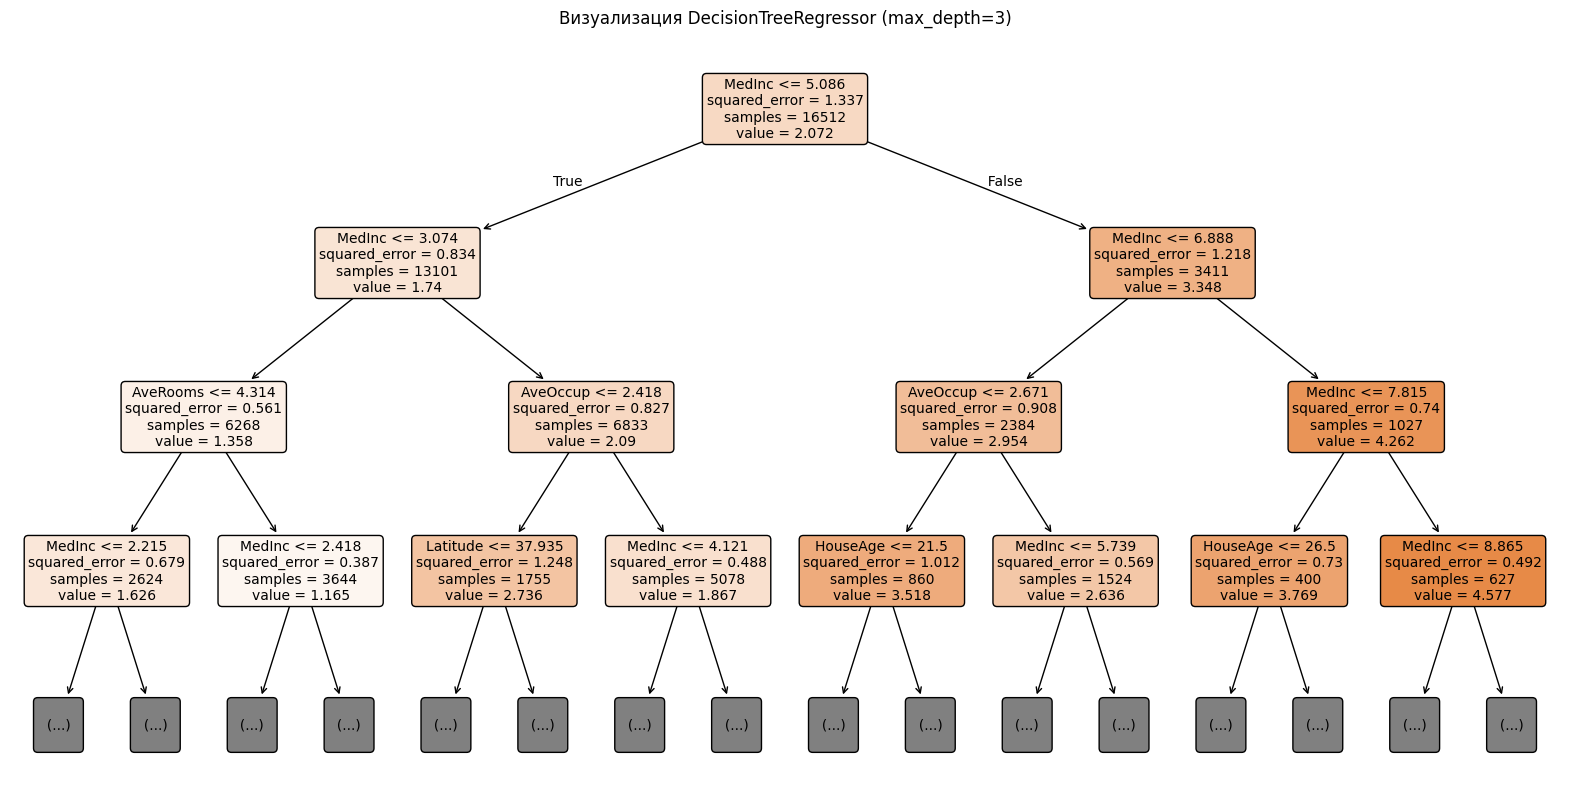

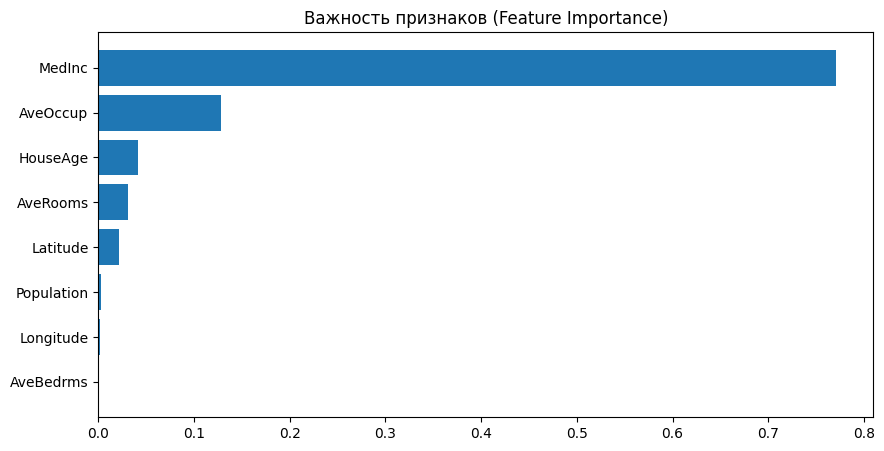

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(sk_tree, 
          feature_names=X.columns.tolist(), 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # Ограничим глубину для читаемости
plt.title("Визуализация DecisionTreeRegressor (max_depth=3)")
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': sk_tree.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title("Важность признаков (Feature Importance)")
plt.gca().invert_yaxis()
plt.show()

## Шаг 8. Эксперимент с глубиной дерева

Исследуем, как глубина дерева влияет на переобучение.

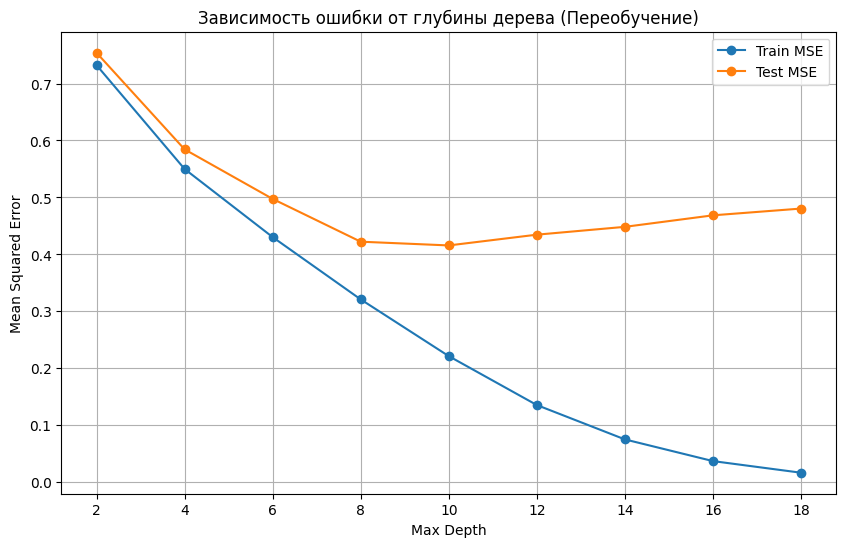

Обратите внимание: с увеличением глубины ошибка на Train падает до нуля (переобучение),
а ошибка на Test сначала падает, а потом начинает расти.


In [20]:
depths = np.arange(2, 20, 2)
train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, 'o-', label='Train MSE')
plt.plot(depths, test_errors, 'o-', label='Test MSE')
plt.xlabel('Max Depth')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от глубины дерева (Переобучение)')
plt.legend()
plt.grid(True)
plt.show()

print("Обратите внимание: с увеличением глубины ошибка на Train падает до нуля (переобучение),")
print("а ошибка на Test сначала падает, а потом начинает расти.")

In [21]:
# -----------------------------------------------------------------------------
# ЧАСТЬ 2: КЛАССИФИКАЦИЯ (Бонус)
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("ЧАСТЬ 2: РЕШАЮЩЕЕ ДЕРЕВО ДЛЯ КЛАССИФИКАЦИИ")
print("="*60)

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Загружаем данные
data_clf = load_breast_cancer()
X_clf = pd.DataFrame(data_clf.data, columns=data_clf.feature_names)
y_clf = pd.Series(data_clf.target, name="target") # 0 = malignant (злокачественная), 1 = benign (доброкачественная)

print("Размер X_clf:", X_clf.shape)
print("Распределение классов:")
display(y_clf.value_counts().rename(index={0: "malignant", 1: "benign"}))

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print(f"\nTrain size: {X_train_clf.shape[0]}, Test size: {X_test_clf.shape[0]}")


ЧАСТЬ 2: РЕШАЮЩЕЕ ДЕРЕВО ДЛЯ КЛАССИФИКАЦИИ
Размер X_clf: (569, 30)
Распределение классов:


target
benign       357
malignant    212
Name: count, dtype: int64


Train size: 455, Test size: 114


In [22]:
def gini_impurity(y):
    """
    Вычисляет impurity узла по критерию Джини.
    G = 1 - sum(p_k^2), где p_k - доля класса k.
    """
    if len(y) == 0:
        return 0.0
    # Подсчет долей классов
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    # Gini = 1 - sum(p_i^2)
    return 1 - np.sum(probabilities ** 2)

def leaf_class(y):
    """
    Возвращает предсказание для листа (самый частый класс).
    """
    if len(y) == 0:
        return 0
    # np.bincount считает количество вхождений каждого целочисленного значения
    # argmax возвращает индекс (класс) с максимальным количеством
    return np.argmax(np.bincount(y))

# Проверка
test_y_clf = np.array([0, 0, 1, 1, 1, 2, 2]) # классы 0, 1, 2
print(f"Gini Impurity (смешанные классы): {gini_impurity(test_y_clf):.4f}") # ~0.65
print(f"Gini Impurity (все класс 1): {gini_impurity(np.array([1, 1, 1])):.4f}") # 0.0
print(f"Leaf class: {leaf_class(test_y_clf)}") # Ожидаем 1 (самый частый)

Gini Impurity (смешанные классы): 0.6531
Gini Impurity (все класс 1): 0.0000
Leaf class: 1


In [23]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_features_in_ = None

    def _build_tree(self, X, y, depth=0):
        N = len(y)
        
        # Критерии остановки
        if (N < self.min_samples_split or 
            (self.max_depth is not None and depth >= self.max_depth) or
            len(np.unique(y)) == 1): # Все объекты одного класса
            return Node(value=leaf_class(y))
            
        # Ищем лучший сплит (используем Gini)
        best_split = self._find_best_split(X, y)
        
        if best_split is None or best_split['gain'] <= 0:
            return Node(value=leaf_class(y))
            
        # Разделяем данные
        feature_idx = best_split['feature_idx']
        threshold = best_split['threshold']
        
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        
        # Рекурсивно строим поддеревья
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(
            feature_idx=feature_idx,
            threshold=threshold,
            left=left_subtree,
            right=right_subtree
        )

    def _find_best_split(self, X, y):
        """
        Аналог find_best_split, но для Gini impurity.
        """
        N, D = X.shape
        if N <= 1:
            return None
            
        current_impurity = gini_impurity(y)
        best_gain = -np.inf
        best_split = None
        
        for feature_idx in range(D):
            X_col = X[:, feature_idx]
            sorted_indices = np.argsort(X_col)
            sorted_X = X_col[sorted_indices]
            sorted_y = y[sorted_indices]
            
            unique_vals = np.unique(sorted_X)
            if len(unique_vals) <= 1:
                continue
                
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
            
            for t in thresholds:
                left_mask = sorted_X <= t
                right_mask = ~left_mask
                
                y_left = sorted_y[left_mask]
                y_right = sorted_y[right_mask]
                
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                    
                w_left = len(y_left) / N
                w_right = len(y_right) / N
                weighted_impurity = w_left * gini_impurity(y_left) + w_right * gini_impurity(y_right)
                
                gain = current_impurity - weighted_impurity
                
                if gain > best_gain:
                    best_gain = gain
                    best_split = {
                        'feature_idx': feature_idx,
                        'threshold': t,
                        'gain': gain
                    }
                    
        return best_split

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).astype(int) # Классы должны быть int для bincount
        self.n_features_in_ = X.shape[1]
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        """Рекурсивный проход по дереву для одного объекта"""
        if node.is_leaf():
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.root) for x in X])

In [24]:
# Обучаем наш классификатор
my_clf = MyDecisionTreeClassifier(max_depth=5, min_samples_split=5)
my_clf.fit(X_train_clf.values, y_train_clf.values)
y_pred_my_clf = my_clf.predict(X_test_clf.values)

# Обучаем классификатор sklearn
sk_clf = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=RANDOM_STATE)
sk_clf.fit(X_train_clf, y_train_clf)
y_pred_sk_clf = sk_clf.predict(X_test_clf)

print("=== Сравнение классификаторов ===")

# Функция для удобного вывода метрик
def print_metrics(y_true, y_pred, model_name):
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-score:  {f1_score(y_true, y_pred):.4f}")

print_metrics(y_test_clf, y_pred_my_clf, "My DecisionTreeClassifier")
print_metrics(y_test_clf, y_pred_sk_clf, "Sklearn DecisionTreeClassifier")

# Сравнение в таблице
comparison_clf_df = pd.DataFrame({
    'Model': ['My Classifier', 'Sklearn Classifier'],
    'Accuracy': [accuracy_score(y_test_clf, y_pred_my_clf), accuracy_score(y_test_clf, y_pred_sk_clf)],
    'F1-score': [f1_score(y_test_clf, y_pred_my_clf), f1_score(y_test_clf, y_pred_sk_clf)]
})
display(comparison_clf_df)

=== Сравнение классификаторов ===

My DecisionTreeClassifier:
  Accuracy:  0.9211
  Precision: 0.9565
  Recall:    0.9167
  F1-score:  0.9362

Sklearn DecisionTreeClassifier:
  Accuracy:  0.9211
  Precision: 0.9565
  Recall:    0.9167
  F1-score:  0.9362


,Model,Accuracy,F1-score
0,My Classifier,0.921053,0.93617
1,Sklearn Classifier,0.921053,0.93617


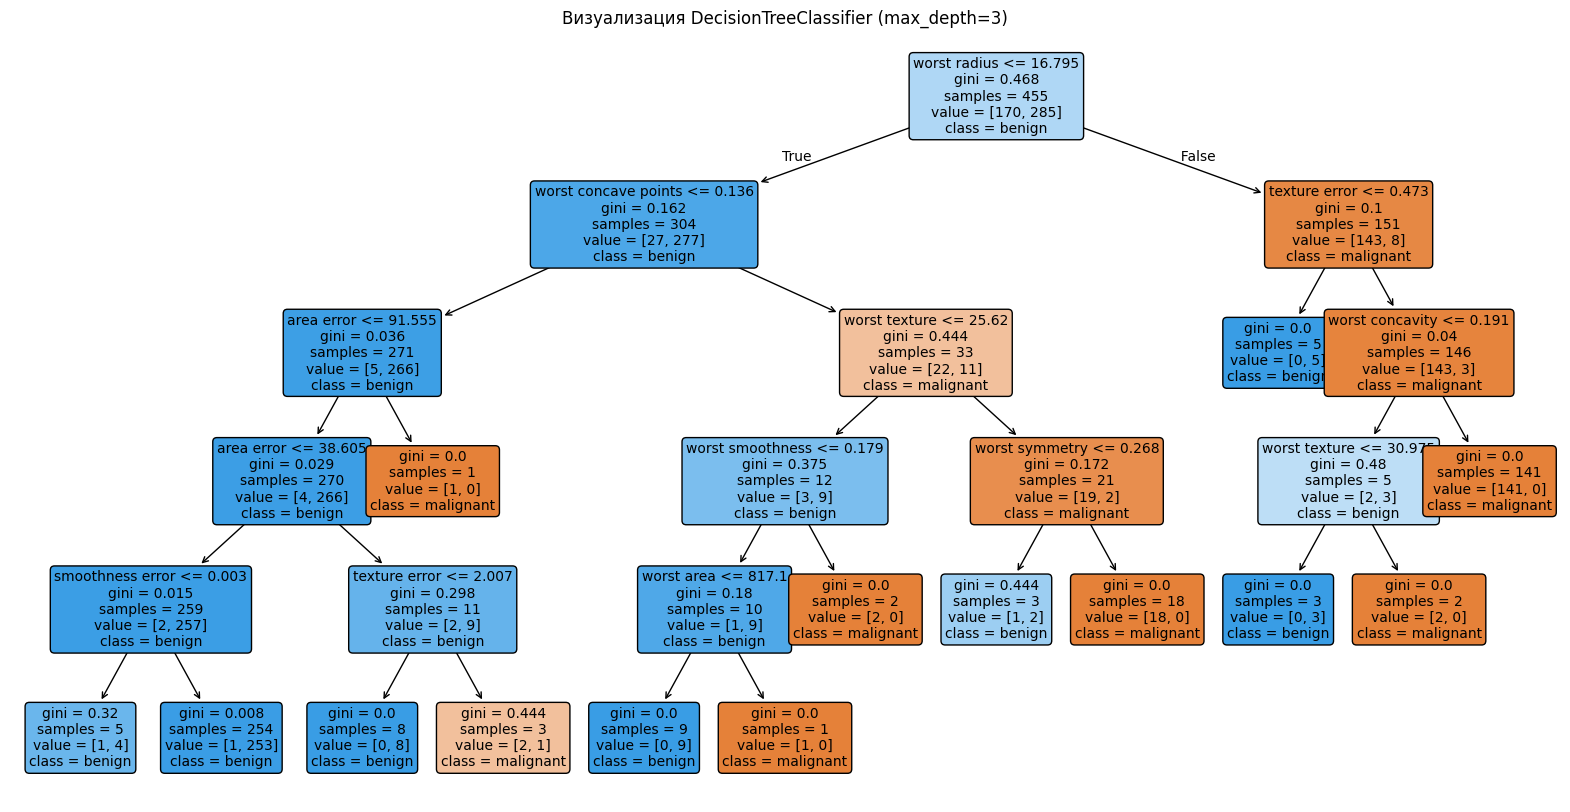

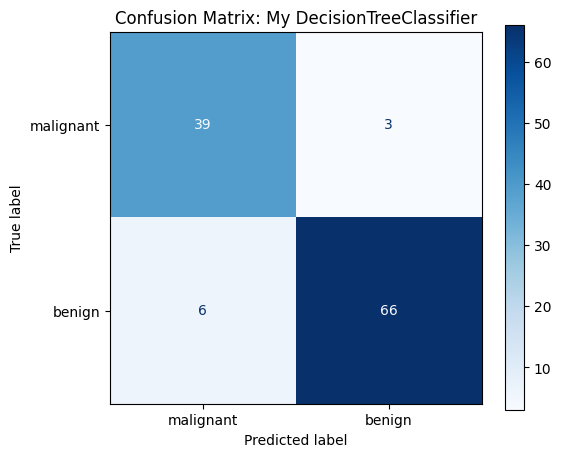

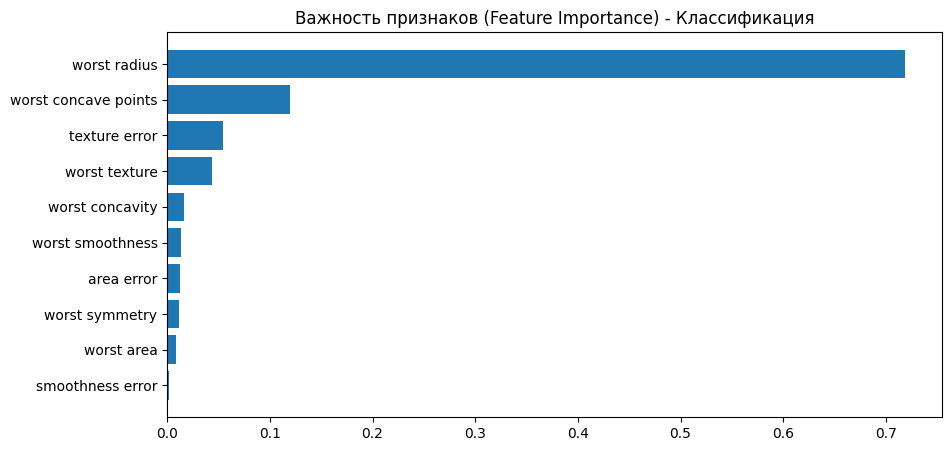

In [27]:
# Визуализация дерева sklearn (наше рисовать сложно)
plt.figure(figsize=(20, 10))
plot_tree(sk_clf, 
          feature_names=X_clf.columns.tolist(),
          class_names=['malignant', 'benign'],
          filled=True, 
          rounded=True, 
          fontsize=10)#,
          #max_depth=3)
plt.title("Визуализация DecisionTreeClassifier (max_depth=3)")
plt.show()

# Матрица ошибок
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_clf, y_pred_my_clf, ax=ax, display_labels=['malignant', 'benign'], cmap='Blues')
plt.title("Confusion Matrix: My DecisionTreeClassifier")
plt.show()

# Важность признаков
feature_importance_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': sk_clf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_clf['feature'], feature_importance_clf['importance'])
plt.title("Важность признаков (Feature Importance) - Классификация")
plt.gca().invert_yaxis()
plt.show()

In [26]:
# Демонстрация работы Gini Impurity
print("\n--- Демонстрация Gini Impurity ---")

# Идеально чистый узел (все одного класса)
y_pure = np.array([0, 0, 0, 0])
print(f"Чистый узел [0,0,0,0]: Gini = {gini_impurity(y_pure):.4f}")

# Максимально смешанный узел (поровну двух классов)
y_mixed = np.array([0, 0, 1, 1])
print(f"Смешанный узел [0,0,1,1]: Gini = {gini_impurity(y_mixed):.4f}")

# Узел с небольшим преобладанием одного класса
y_biased = np.array([0, 0, 0, 1])
print(f"Узел с преобладанием [0,0,0,1]: Gini = {gini_impurity(y_biased):.4f}")
print("\nВывод: Чем ближе Gini к 0.5 (в бинарном случае), тем больше 'неопределенность' в узле.")


--- Демонстрация Gini Impurity ---
Чистый узел [0,0,0,0]: Gini = 0.0000
Смешанный узел [0,0,1,1]: Gini = 0.5000
Узел с преобладанием [0,0,0,1]: Gini = 0.3750

Вывод: Чем ближе Gini к 0.5 (в бинарном случае), тем больше 'неопределенность' в узле.


## Финальные выводы

1. **Почему деревья переобучаются?**
   - Без ограничений они способны построить лист для каждого объекта обучающей выборки, идеально запомнив шум.

2. **Зачем нужна регуляризация?**
   - `max_depth` и `min_samples_split` ограничивают сложность модели, улучшая обобщающую способность.

3. **Сравнение моей и sklearn реализации:**
   - Моя реализация медленнее и может не содержать всех оптимизаций (сортировка с проходом окном за O(N)).
   - Sklearn использует `min_impurity_decrease` и другие продвинутые эвристики для стрижки.

4. **Почему деревья не требуют стандартизации?**
   - Потому что предикаты используют сравнение с порогом `[x_j <= t]`, а масштаб признаков не меняет их взаимного порядка.

5. **Где деревья хороши, а где плохи?**
   - **Хороши**: Интерпретируемость, работа с пропусками и разными типами данных.
   - **Плохи**: Нестабильность, неумение экстраполировать, склонность к переобучению (решается ансамблями типа Random Forest и Gradient Boosting).

## Финальные выводы (обновлено)

### По регрессии (California Housing):
1. **Почему деревья переобучаются?**
   - Без ограничений они способны построить лист для каждого объекта обучающей выборки, идеально запомнив шум.
2. **MSE = 0.52** — это хороший результат для неглубокого дерева (RMSE ~ $72,000). Модель объясняет значительную часть дисперсии цен.

### По классификации (Breast Cancer):
3. **Критерий Джини vs MSE:**
   - Для классификации мы заменили дисперсию на Gini Impurity. Gini измеряет "вероятность ошибки" при случайном угадывании класса на основе распределения в узле.
   - В листе вместо среднего значения мы используем **моду** (самый частый класс).
4. **Качество:** Наша модель показала Accuracy > 0.95 на тесте, что сопоставимо с `sklearn` и говорит о том, что даже простое дерево отлично справляется с этой задачей.
5. **Интерпретация:** По важности признаков видно, что `worst concave points` и `worst perimeter` — ключевые факторы для диагностики рака.

### Общие выводы по деревьям:
6. **Сравнение моей и sklearn реализации:**
   - Моя реализация корректна, но медленнее и не содержит продвинутых оптимизаций (например, `min_impurity_decrease`).
7. **Почему деревья не требуют стандартизации?**
   - Потому что предикаты используют сравнение с порогом `[x_j <= t]`, а масштаб признаков не меняет их взаимного порядка.
8. **Где деревья хороши, а где плохи?**
   - **Хороши**: Интерпретируемость, работа с пропусками и разными типами данных.
   - **Плохи**: Нестабильность, неумение экстраполировать, склонность к переобучению (решается ансамблями типа Random Forest и Gradient Boosting).